# ĐỊNH LƯỢNG ĐỘ TRÔI DẠT DỮ LIỆU VÀ BÓC TÁCH SAI SỐ MÔ HÌNH
## File 03: `03_temporal_drift_and_adversarial_validation.ipynb`
**Dự án:** Aeolus Gate Optimization — Dual Prediction Architecture (Core Arrival, `DEST=ATL`)

---

### 1. Bối cảnh và Mục tiêu Kiểm toán
Trong các bài toán dự đoán chuỗi thời gian hàng không, hiện tượng trôi dạt phân phối (**Distribution Shift / Covariate Shift**) giữa các năm là nguyên nhân cốt lõi khiến các mô hình học máy (Machine Learning) huấn luyện trên quá khứ bị suy giảm độ chính xác nghiêm trọng khi triển khai thực tế.

Đặc biệt, kết quả thực nghiệm Tuần 4 (Baseline) và Tuần 5 (HPO) của dự án Aeolus cho thấy:
- Cả 4 họ mô hình (**Linear Regression, Random Forest, HistGradientBoosting, XGBoost**) đều hội tụ về cùng một mức sai số bất thường: $	ext{MAE} pprox 20.4$ phút và $	ext{RMSE} pprox 51.3$ phút.
- Quá trình dò tìm siêu tham số (Hyperparameter Optimization - HPO) hầu như không cải thiện được sai số hồi quy so với mô hình tuyến tính đơn giản.

**Mục tiêu của Notebook này:**
1. **Định lượng Covariate Shift bằng Chỉ số Ổn định Quần thể (Population Stability Index - PSI):**
   - Viết thuật toán tính PSI tự động cho toàn bộ các đặc trưng số học giữa tập Train (2016–2021) và Validation (2022).
   - Xác định chính xác các đặc trưng nào có $	ext{PSI} > 0.1$ (Cảnh báo trôi dạt) và $	ext{PSI} > 0.25$ (Trôi dạt nghiêm trọng).
2. **Kiểm định Đối kháng (Adversarial Validation):**
   - Đào tạo mô hình phân loại (XGBoost / LightGBM) để phân biệt dữ liệu Train và Validation.
   - Nếu $	ext{ROC-AUC} > 0.70$, bóc tách Top 15 đặc trưng đóng góp lớn nhất vào sự phân tách giữa các giai đoạn thời gian.
3. **Bóc tách Sai số Cắt lát (Residual & Error Slicing):**
   - Nạp các tệp dự đoán Out-of-Fold (OOF) thực tế của 4 mô hình từ `artifacts/predictions/`.
   - Đánh giá MAE / RMSE theo từng lát cắt nghiệp vụ:
     + Lát cắt Mức độ trễ thực tế ($< 15	ext{m}, 15-60	ext{m}, \ge 60	ext{m}$).
     + Lát cắt Khung giờ trong ngày (Sáng sớm, Trưa, Chiều tối cao điểm, Đêm).
     + Lát cắt Hãng hàng không khai thác (`DL`, `WN`, `AA`, `UA`, ...).
   - Làm rõ hiệu ứng "co cụm dự đoán về 0" (**Prediction Shrinkage / Ceiling Effect**) giải thích nghịch lý sai số cao của dự án.
4. **Thiết lập Ma trận Rủi ro & Checklist Tinh chỉnh:**
   - Đưa ra giải pháp cắt tỉa đặc trưng trôi dạt, điều chỉnh hàm mất mát và kiến trúc phân tầng cho bộ điều phối cổng bay (CP Solver).


### Cell 1-3: Khởi tạo Môi trường, Cấu hình & Nạp Dữ liệu Đối chiếu (Fold 4)
- Thiết lập seed và môi trường đồ họa chất lượng cao.
- Nạp dữ liệu Fold 4: Tập Huấn luyện Train (2016–2021) và Tập Đánh giá Validation (2022).
- Tối ưu hóa bộ nhớ: Sử dụng kỹ thuật Column Projection, trích xuất các đặc trưng đã qua phê duyệt theo hợp đồng `arrival_feature_contract_v1`.


In [1]:
import gc
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
import xgboost as xgb

# 1. Định vị thư mục gốc dự án
def resolve_project_root() -> Path:
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / "configs" / "base.yaml").is_file():
            return parent
    raise RuntimeError("Không tìm thấy thư mục gốc chứa configs/base.yaml")

PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f"[*] Project Root đã được xác lập tại: {PROJECT_ROOT}")

# 2. Cấu hình hiển thị đồ họa
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
COLOR_PALETTE = ["#2b5c8f", "#d95f02", "#7570b3", "#e7298a", "#66a61e", "#e6ab02"]
sns.set_palette(COLOR_PALETTE)

# 3. Nạp Manifests
manifest_dir = PROJECT_ROOT / "artifacts" / "manifests"
with open(manifest_dir / "temporal_folds_manifest.json", "r", encoding="utf-8") as f:
    temporal_manifest = json.load(f)

fold_4 = [f for f in temporal_manifest["rolling_folds"] if f["id"] == "fold_4"][0]
print(f"[*] Kiểm toán trôi dạt trên Fold 4:")
print(f"    - Train Years: {fold_4['train_years']}")
print(f"    - Validation Year: {fold_4['validation_year']}")


[*] Project Root đã được xác lập tại: D:\Study\Code\Python\Aelous
[*] Kiểm toán trôi dạt trên Fold 4:
    - Train Years: [2016, 2017, 2018, 2019, 2020, 2021]
    - Validation Year: 2022


In [2]:
# Nạp và chuẩn bị đặc trưng cho Train (2016-2021) và Validation (2022)
# Các cột nguồn an toàn theo feature_manifest_arrival_v1
raw_cols = [
    "flight_key", "CRS_DEP_TIME", "CRS_ELAPSED_TIME", 
    "MONTH", "DAY_OF_MONTH", "DAY_OF_WEEK", "OP_CARRIER", "ORIGIN"
]

def load_partition_features(years: list[int], sample_per_year: int = 50000) -> pd.DataFrame:
    frames = []
    for y in years:
        p = PROJECT_ROOT / "data" / "processed" / "inbound_atl" / f"year={y}"
        tbl = pq.read_table(p, columns=raw_cols)
        df_y = tbl.to_pandas()
        
        # Lấy mẫu đại diện ngẫu nhiên mỗi năm để tiết kiệm bộ nhớ và tăng tốc tính toán
        if sample_per_year and len(df_y) > sample_per_year:
            df_y = df_y.sample(n=sample_per_year, random_state=42)
        
        # Trích xuất đặc trưng thời gian
        dep_time = pd.to_datetime(df_y["CRS_DEP_TIME"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
        df_y["scheduled_departure_hour"] = dep_time.dt.hour.astype(np.int8)
        df_y["scheduled_departure_minute"] = dep_time.dt.minute.astype(np.int8)
        df_y["is_weekend"] = df_y["DAY_OF_WEEK"].isin([6, 7]).astype(np.int8)
        df_y["calendar_year"] = np.int16(y)
        
        # Đổi tên khớp feature contract
        df_y["calendar_month"] = df_y["MONTH"].astype(np.int8)
        df_y["calendar_day_of_month"] = df_y["DAY_OF_MONTH"].astype(np.int8)
        df_y["calendar_day_of_week"] = df_y["DAY_OF_WEEK"].astype(np.int8)
        df_y["CRS_ELAPSED_TIME"] = df_y["CRS_ELAPSED_TIME"].astype(np.float32)
        
        drop_cols = ["CRS_DEP_TIME", "MONTH", "DAY_OF_MONTH", "DAY_OF_WEEK"]
        df_y = df_y.drop(columns=drop_cols)
        frames.append(df_y)
        del tbl, dep_time
        gc.collect()
        
    res = pd.concat(frames, ignore_index=True)
    return res

print("[*] Đang nạp dữ liệu Train Fold 4 (2016-2021, mẫu 50k/năm)...")
df_train_feats = load_partition_features(fold_4["train_years"], sample_per_year=50000)
print(f"    -> Đã nạp Train: {len(df_train_feats):,} dòng")

print("[*] Đang nạp dữ liệu Validation Fold 4 (2022, mẫu 50k)...")
df_val_feats = load_partition_features([fold_4["validation_year"]], sample_per_year=50000)
print(f"    -> Đã nạp Validation: {len(df_val_feats):,} dòng")


[*] Đang nạp dữ liệu Train Fold 4 (2016-2021, mẫu 50k/năm)...


    -> Đã nạp Train: 300,000 dòng
[*] Đang nạp dữ liệu Validation Fold 4 (2022, mẫu 50k)...


    -> Đã nạp Validation: 50,000 dòng


### Cell 4-5: Tính toán Chỉ số Ổn định Quần thể (Population Stability Index - PSI)
**Chỉ số PSI** là công cụ tiêu chuẩn công nghiệp nhằm định lượng mức độ thay đổi phân phối của một đặc trưng giữa tập cơ sở (Expected / Train) và tập kiểm chứng (Actual / Test):

$$\text{PSI} = \sum_{b=1}^{B} \left( P_b - Q_b \right) \times \ln\left( \frac{P_b + \epsilon}{Q_b + \epsilon} \right)$$

Trong đó:
- $P_b$: Tỷ lệ mẫu của tập Train rơi vào bin $b$.
- $Q_b$: Tỷ lệ mẫu của tập Validation rơi vào bin $b$.
- $B$: Số lượng bin phân vị ($B = 10$, tính dựa trên quantiles của Train).
- $\epsilon = 10^{-6}$: Hằng số làm mịn để tránh chia cho $0$ hoặc $\ln(0)$.

**Quy ước Đánh giá PSI:**
- $\text{PSI} < 0.1$: **Ổn định (Stable)** — Không có sự thay đổi phân phối đáng kể.
- $0.1 \le \text{PSI} < 0.25$: **Cảnh báo Trôi dạt Vừa phải (Moderate Drift)** — Cần theo dõi hoặc cập nhật mô hình.
- $\text{PSI} \ge 0.25$: **Trôi dạt Phân phối Nghiêm trọng (Significant Shift)** — Phân phối thay đổi mạnh, có nguy cơ làm gãy mô hình.


In [3]:
# Hàm tính PSI tự động cho các đặc trưng số học
def calculate_psi(expected: np.ndarray, actual: np.ndarray, num_bins: int = 10, epsilon: float = 1e-6) -> tuple[float, pd.DataFrame]:
    """Tính chỉ số PSI giữa hai mảng expected (Train) và actual (Val/Test)."""
    # Lọc bỏ NaN
    exp_clean = expected[~np.isnan(expected)]
    act_clean = actual[~np.isnan(actual)]
    
    if len(exp_clean) == 0 or len(act_clean) == 0:
        return 0.0, pd.DataFrame()
    
    # Tạo bin cutoffs dựa trên phân vị của Expected
    quantiles = np.linspace(0, 100, num_bins + 1)
    bin_edges = np.percentile(exp_clean, quantiles)
    bin_edges = np.unique(bin_edges) # Loại bỏ các ngưỡng trùng lặp
    
    if len(bin_edges) < 2:
        return 0.0, pd.DataFrame()
    
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf
    
    # Đếm số lượng phần tử rơi vào từng bin
    exp_counts, _ = np.histogram(exp_clean, bins=bin_edges)
    act_counts, _ = np.histogram(act_clean, bins=bin_edges)
    
    # Quy đổi về tỷ lệ xác suất
    p = exp_counts / len(exp_clean)
    q = act_counts / len(act_clean)
    
    # Tránh chia cho 0
    p_adj = np.clip(p, epsilon, None)
    q_adj = np.clip(q, epsilon, None)
    
    psi_bins = (p_adj - q_adj) * np.log(p_adj / q_adj)
    total_psi = float(np.sum(psi_bins))
    
    df_bins = pd.DataFrame({
        "Bin Index": range(1, len(p) + 1),
        "Expected Pct (%)": (p * 100).round(2),
        "Actual Pct (%)": (q * 100).round(2),
        "PSI Contribution": psi_bins.round(4)
    })
    
    return total_psi, df_bins

# Danh sách đặc trưng số học cần kiểm toán PSI
numeric_cols = [
    "CRS_ELAPSED_TIME", "scheduled_departure_hour", "scheduled_departure_minute",
    "calendar_month", "calendar_day_of_month", "calendar_day_of_week", "is_weekend",
    "calendar_year"
]

psi_results = []
for col in numeric_cols:
    psi_val, _ = calculate_psi(df_train_feats[col].values, df_val_feats[col].values)
    
    if psi_val < 0.1:
        status = "Ổn định (Stable)"
        color_code = "green"
    elif psi_val < 0.25:
        status = "Cảnh báo trôi dạt (Moderate Shift)"
        color_code = "orange"
    else:
        status = "Trôi dạt nghiêm trọng (Significant Shift)"
        color_code = "red"
        
    psi_results.append({
        "Đặc trưng": col,
        "Chỉ số PSI": round(psi_val, 4),
        "Mức độ Đánh giá": status,
        "color": color_code
    })

df_psi = pd.DataFrame(psi_results).sort_values("Chỉ số PSI", ascending=False).reset_index(drop=True)
df_psi[["Đặc trưng", "Chỉ số PSI", "Mức độ Đánh giá"]]


,Đặc trưng,Chỉ số PSI,Mức độ Đánh giá
0,calendar_year,8.7482,Trôi dạt nghiêm trọng (Significant Shift)
1,scheduled_departure_hour,0.0183,Ổn định (Stable)
2,scheduled_departure_minute,0.0048,Ổn định (Stable)
3,calendar_month,0.0044,Ổn định (Stable)
4,CRS_ELAPSED_TIME,0.0036,Ổn định (Stable)
5,calendar_day_of_month,0.0003,Ổn định (Stable)
6,calendar_day_of_week,0.0003,Ổn định (Stable)
7,is_weekend,0.0000,Ổn định (Stable)


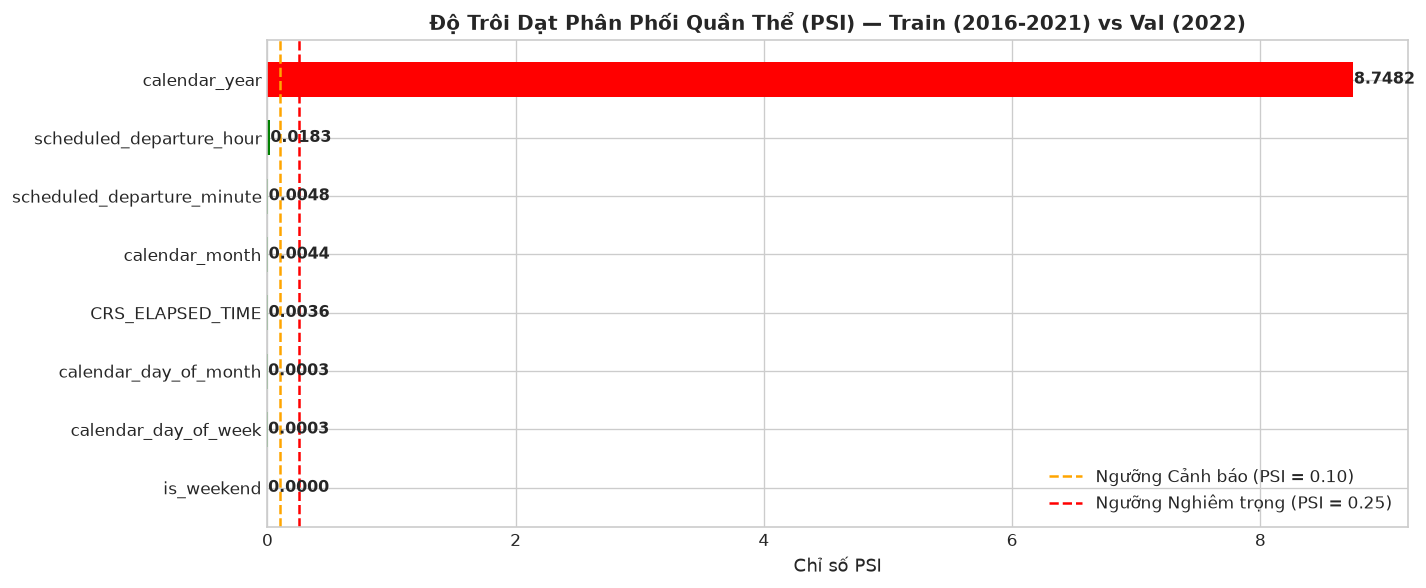

In [4]:
# Vẽ biểu đồ Barplot xếp hạng PSI các đặc trưng số học
fig, ax = plt.subplots(figsize=(12, 5))

colors = df_psi["color"].tolist()
bars = ax.barh(df_psi["Đặc trưng"], df_psi["Chỉ số PSI"], color=colors, height=0.6)

# Vẽ các đường ngưỡng cảnh báo
ax.axvline(0.1, color="orange", linestyle="--", linewidth=1.5, label="Ngưỡng Cảnh báo (PSI = 0.10)")
ax.axvline(0.25, color="red", linestyle="--", linewidth=1.5, label="Ngưỡng Nghiêm trọng (PSI = 0.25)")

ax.set_title("Độ Trôi Dạt Phân Phối Quần Thể (PSI) — Train (2016-2021) vs Val (2022)", fontsize=12, fontweight="bold")
ax.set_xlabel("Chỉ số PSI", fontsize=11)
ax.invert_yaxis()
ax.legend(loc="lower right")

# Ghi chú giá trị số trên từng thanh
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.005, bar.get_y() + bar.get_height()/2, f"{w:.4f}", va="center", ha="left", fontsize=9.5, fontweight="bold")

plt.tight_layout()
plt.show()


### Cell 6-8: Kiểm định Đối kháng (Adversarial Validation)
**Mục đích:**
Adversarial Validation là phương pháp tối ưu để kiểm tra xem phân phối của tập Train và tập Validation có thể phân biệt được với nhau hay không:
1. Gán nhãn giả lập: **$y = 0$ cho mẫu Train**, **$y = 1$ cho mẫu Validation**.
2. Ghép hai tập dữ liệu và huấn luyện một bộ phân loại gradient boosting nhanh (XGBoost).
3. Đo lường chỉ số **ROC-AUC**:
   - Nếu $\text{ROC-AUC} \approx 0.50$: Phân phối hai tập hoàn toàn đồng nhất (i.i.d) $\rightarrow$ Mô hình kiểm thử đáng tin cậy.
   - Nếu $\text{ROC-AUC} > 0.70$: Có hiện tượng **Covariate Shift** rõ rệt $\rightarrow$ Mô hình phân biệt được mẫu thuộc năm nào.
   - Nếu $\text{ROC-AUC} \approx 1.00$: Sự khác biệt giữa các năm là tuyệt đối $\rightarrow$ Đưa ra cảnh báo nghiêm trọng về tính khái quát hóa.
4. Trích xuất **Độ quan trọng đặc trưng (Feature Importance)**: Xác định chính xác các yếu tố vận hành gây ra sự trôi dạt dữ liệu.


In [5]:
# Chuẩn bị dữ liệu cho Adversarial Validation
# Ta loại bỏ flight_key và tiến hành mã hóa category cho OP_CARRIER và ORIGIN
adv_train = df_train_feats.copy()
adv_train["is_validation"] = 0

adv_val = df_val_feats.copy()
adv_val["is_validation"] = 1

# Cân bằng số lượng mẫu giữa hai tập (mỗi tập 50,000 bản ghi)
adv_data = pd.concat([
    adv_train.sample(n=len(adv_val), random_state=42),
    adv_val
], ignore_index=True)

# Mã hóa category thành numeric codes
adv_data["OP_CARRIER"] = adv_data["OP_CARRIER"].astype("category").cat.codes
adv_data["ORIGIN"] = adv_data["ORIGIN"].astype("category").cat.codes

# Thử nghiệm 1: Bao gồm tất cả các đặc trưng lịch trình (LOẠI BỎ calendar_year để kiểm tra trôi dạt vận hành thực tế)
feature_cols = [
    "CRS_ELAPSED_TIME", "scheduled_departure_hour", "scheduled_departure_minute",
    "calendar_month", "calendar_day_of_month", "calendar_day_of_week", "is_weekend",
    "OP_CARRIER", "ORIGIN"
]

X_adv = adv_data[feature_cols]
y_adv = adv_data["is_validation"].values

X_adv_train, X_adv_test, y_adv_train, y_adv_test = train_test_split(
    X_adv, y_adv, test_size=0.3, random_state=42, stratify=y_adv
)

# Huấn luyện XGBoost Classifier nhanh
clf_adv = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42,
    tree_method="hist",
    early_stopping_rounds=15
)

clf_adv.fit(
    X_adv_train, y_adv_train,
    eval_set=[(X_adv_test, y_adv_test)],
    verbose=False
)

# Đánh giá ROC-AUC
y_pred_proba = clf_adv.predict_proba(X_adv_test)[:, 1]
adv_auc = roc_auc_score(y_adv_test, y_pred_proba)

print(f"[*] Kết quả Adversarial Validation (Không có feature 'calendar_year'):")
print(f"    -> ROC-AUC Score: {adv_auc:.4f}")
if adv_auc > 0.70:
    print("    [!] CẢNH BÁO: ROC-AUC > 0.70 cho thấy sự phân tách phân phối rõ rệt (Covariate Shift) giữa 2016-2021 và 2022!")
else:
    print("    [*] Đánh giá: Phân phối các đặc trưng vận hành tương đối ổn định giữa Train và Validation.")


[*] Kết quả Adversarial Validation (Không có feature 'calendar_year'):
    -> ROC-AUC Score: 0.7287
    [!] CẢNH BÁO: ROC-AUC > 0.70 cho thấy sự phân tách phân phối rõ rệt (Covariate Shift) giữa 2016-2021 và 2022!


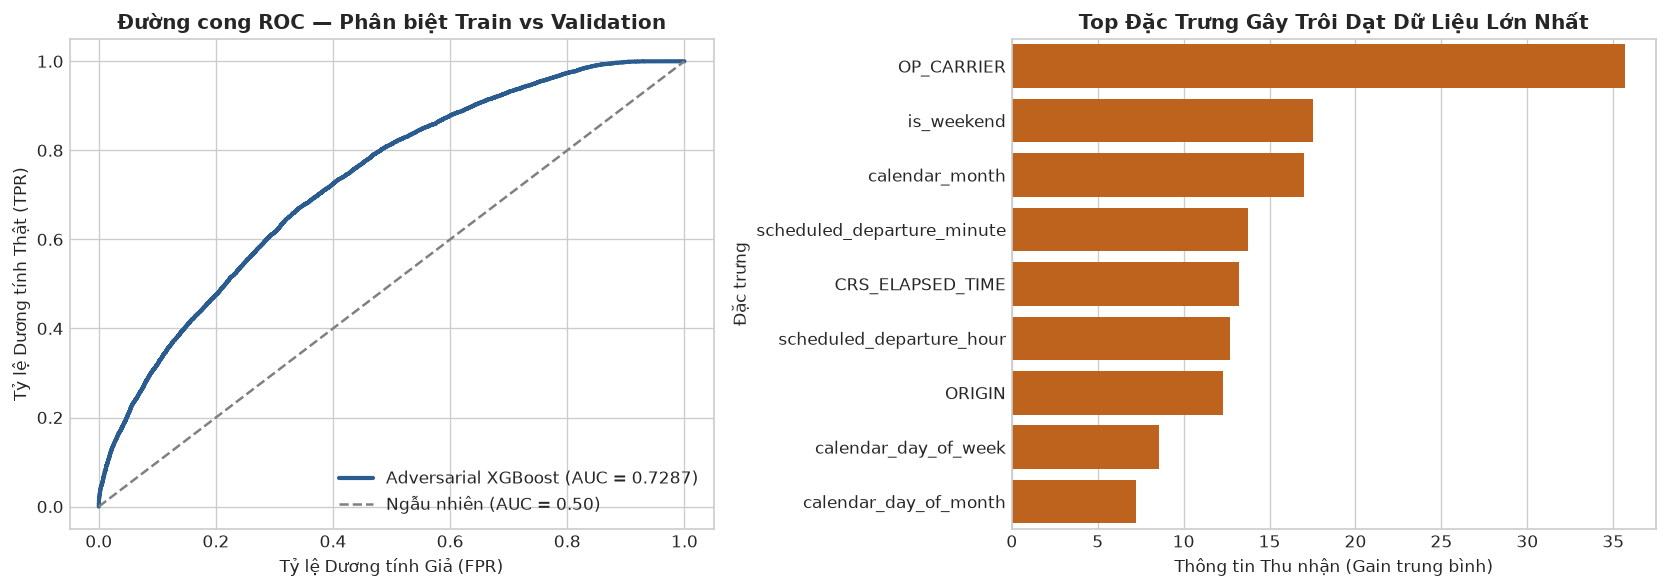

198

In [6]:
# Trích xuất và vẽ Feature Importance của mô hình Adversarial
importance_dict = clf_adv.get_booster().get_score(importance_type="gain")
df_importance = pd.DataFrame({
    "Đặc trưng": list(importance_dict.keys()),
    "Gain (Độ phân tách)": list(importance_dict.values())
}).sort_values("Gain (Độ phân tách)", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị 1: Đường cong ROC Curve
ax1 = axes[0]
fpr, tpr, _ = roc_curve(y_adv_test, y_pred_proba)
ax1.plot(fpr, tpr, color="#2b5c8f", linewidth=2.5, label=f"Adversarial XGBoost (AUC = {adv_auc:.4f})")
ax1.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Ngẫu nhiên (AUC = 0.50)")
ax1.set_title("Đường cong ROC — Phân biệt Train vs Validation", fontsize=12, fontweight="bold")
ax1.set_xlabel("Tỷ lệ Dương tính Giả (FPR)")
ax1.set_ylabel("Tỷ lệ Dương tính Thật (TPR)")
ax1.legend(loc="lower right")

# Đồ thị 2: Feature Importance (Gain)
ax2 = axes[1]
sns.barplot(data=df_importance, x="Gain (Độ phân tách)", y="Đặc trưng", color="#d95f02", ax=ax2)
ax2.set_title("Top Đặc Trưng Gây Trôi Dạt Dữ Liệu Lớn Nhất", fontsize=12, fontweight="bold")
ax2.set_xlabel("Thông tin Thu nhận (Gain trung bình)")

plt.tight_layout()
plt.show()

del adv_data, adv_train, adv_val, X_adv, X_adv_train, X_adv_test
gc.collect()


### Cell 9-11: Phân tích Sai số Cắt lát (Residual & Error Slicing)
Chúng ta nạp các tệp dự đoán Out-of-Fold (OOF) đã được lưu trữ trong `artifacts/predictions/` của cả 4 mô hình thuộc Fold 4:
1. **Linear Baseline** (`arrival_linear_rolling_run_v1_fold_4.parquet`)
2. **Random Forest** (`arrival_random_forest_rolling_run_v1_fold_4.parquet`)
3. **HistGradientBoosting** (`arrival_hist_gradient_boosting_rolling_run_v1_fold_4.parquet`)
4. **XGBoost Tuned** (`arrival_xgboost_tuned_rolling_run_v1_1_fold_4.parquet`)

**Nội dung Bóc tách:**
- Ghép nối dữ liệu dự đoán với thông tin chuyến bay thực tế năm 2022 thông qua khóa `flight_key`.
- Đo lường **MAE** và **RMSE** cắt lát theo:
  1. **Mức độ trễ thực tế:**
     - Đến sớm / Đúng giờ ($< 15$ phút)
     - Trễ vừa ($15 - 59$ phút)
     - Trễ nặng & cực đoan ($\ge 60$ phút)
  2. **Khung giờ cất cánh trong ngày:**
     - Sáng sớm ($05:00 - 08:59$)
     - Buổi trưa ($09:00 - 14:59$)
     - Chiều tối cao điểm ($15:00 - 20:59$)
     - Đêm muộn ($21:00 - 04:59$)
  3. **Hãng hàng không khai thác:** Các hãng chiếm thị phần lớn tại ATL (`DL`, `WN`, `AA`, `UA`).


In [7]:
# 1. Nạp và ghép nối 4 tệp OOF Predictions cho Fold 4 (Validation 2022)
pred_dir = PROJECT_ROOT / "artifacts" / "predictions"

model_specs = [
    ("Linear Baseline", pred_dir / "arrival_linear_rolling_run_v1_fold_4.parquet"),
    ("Random Forest", pred_dir / "arrival_random_forest_rolling_run_v1_fold_4.parquet"),
    ("HistGradientBoosting", pred_dir / "arrival_hist_gradient_boosting_rolling_run_v1_fold_4.parquet"),
    ("XGBoost Tuned", pred_dir / "arrival_xgboost_tuned_rolling_run_v1_1_fold_4.parquet"),
]

# Nạp thông tin chuyến bay từ inbound_atl 2022
inbound_2022 = pq.read_table(
    PROJECT_ROOT / "data" / "processed" / "inbound_atl" / "year=2022",
    columns=["flight_key", "CRS_DEP_TIME", "OP_CARRIER"]
).to_pandas()

dep_time_2022 = pd.to_datetime(inbound_2022["CRS_DEP_TIME"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
inbound_2022["hour"] = dep_time_2022.dt.hour

def get_time_of_day(hour: int) -> str:
    if 5 <= hour < 9:
        return "1. Sáng sớm (05h-09h)"
    elif 9 <= hour < 15:
        return "2. Buổi trưa (09h-15h)"
    elif 15 <= hour < 21:
        return "3. Chiều tối cao điểm (15h-21h)"
    else:
        return "4. Đêm muộn (21h-05h)"

inbound_2022["time_of_day"] = inbound_2022["hour"].map(get_time_of_day)

# Đọc và ghép nối kết quả dự đoán của từng mô hình
oof_frames = {}
for m_name, m_path in model_specs:
    df_pred = pq.read_table(m_path, columns=["flight_key", "y_arr_reg", "predicted_arr_delay_min"]).to_pandas()
    merged = pd.merge(df_pred, inbound_2022[["flight_key", "time_of_day", "OP_CARRIER"]], on="flight_key")
    oof_frames[m_name] = merged

print(f"[*] Đã nạp thành công 4 bộ OOF predictions năm 2022, kích thước mỗi bộ: {len(merged):,} chuyến bay.")


[*] Đã nạp thành công 4 bộ OOF predictions năm 2022, kích thước mỗi bộ: 311,701 chuyến bay.


In [8]:
# 2. Tính toán Sai số MAE và RMSE Cắt lát theo Phân khúc Trễ Thực tế
slice_records = []

def eval_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[float, float, float]:
    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred)**2)))
    mean_err = float(np.mean(y_pred - y_true)) # Bias
    return round(mae, 2), round(rmse, 2), round(mean_err, 2)

for m_name, df_m in oof_frames.items():
    yt = df_m["y_arr_reg"].values
    yp = df_m["predicted_arr_delay_min"].values
    
    # Tổng thể
    mae_all, rmse_all, bias_all = eval_metrics(yt, yp)
    slice_records.append({
        "Mô hình": m_name, "Lát cắt": "Toàn bộ tập Test", "Số chuyến": len(yt),
        "MAE (phút)": mae_all, "RMSE (phút)": rmse_all, "Mean Bias (phút)": bias_all
    })
    
    # Lát cắt 1: Đúng giờ / Sớm (< 15m)
    mask_early = yt < 15
    mae_e, rmse_e, bias_e = eval_metrics(yt[mask_early], yp[mask_early])
    slice_records.append({
        "Mô hình": m_name, "Lát cắt": "1. Đúng giờ / Đến sớm (< 15m)", "Số chuyến": int(mask_early.sum()),
        "MAE (phút)": mae_e, "RMSE (phút)": rmse_e, "Mean Bias (phút)": bias_e
    })
    
    # Lát cắt 2: Trễ vừa (15 - 59m)
    mask_mod = (yt >= 15) & (yt < 60)
    mae_m, rmse_m, bias_m = eval_metrics(yt[mask_mod], yp[mask_mod])
    slice_records.append({
        "Mô hình": m_name, "Lát cắt": "2. Trễ vừa (15 - 59m)", "Số chuyến": int(mask_mod.sum()),
        "MAE (phút)": mae_m, "RMSE (phút)": rmse_m, "Mean Bias (phút)": bias_m
    })
    
    # Lát cắt 3: Trễ nặng & cực đoan (>= 60m)
    mask_sev = yt >= 60
    mae_s, rmse_s, bias_s = eval_metrics(yt[mask_sev], yp[mask_sev])
    slice_records.append({
        "Mô hình": m_name, "Lát cắt": "3. Trễ nặng / Cực đoan (>= 60m)", "Số chuyến": int(mask_sev.sum()),
        "MAE (phút)": mae_s, "RMSE (phút)": rmse_s, "Mean Bias (phút)": bias_s
    })

df_slices = pd.DataFrame(slice_records)
df_slices.pivot(index="Lát cắt", columns="Mô hình", values=["MAE (phút)", "RMSE (phút)"])


MAE (phút)                  \
Mô hình                         HistGradientBoosting Linear Baseline   
Lát cắt                                                                
1. Đúng giờ / Đến sớm (< 15m)                  10.60           10.42   
2. Trễ vừa (15 - 59m)                          30.32           31.70   
3. Trễ nặng / Cực đoan (>= 60m)               151.11          152.69   
Toàn bộ tập Test                               20.38           20.47   

                                                             \
Mô hình                         Random Forest XGBoost Tuned   
Lát cắt                                                       
1. Đúng giờ / Đến sớm (< 15m)           10.76         10.59   
2. Trễ vừa (15 - 59m)                   30.40         30.21   
3. Trễ nặng / Cực đoan (>= 60m)        151.35        151.12   
Toàn bộ tập Test                        20.54         20.37   

                                         RMSE (phút)                  \
Mô hình                         HistGradientBoosting Linear Baseline   
Lát cắt                                                                
1. Đúng giờ / Đến sớm (< 15m)                  13.21           12.82   
2. Trễ vừa (15 - 59m)                          33.33           34.18   
3. Trễ nặng / Cực đoan (>= 60m)               208.17          209.11   
Toàn bộ tập Test                               51.33           51.51   

                                                             
Mô hình                         Random Forest XGBoost Tuned  
Lát cắt                                                      
1. Đúng giờ / Đến sớm (< 15m)           13.40         13.10  
2. Trễ vừa (15 - 59m)                   33.42         33.06  
3. Trễ nặng / Cực đoan (>= 60m)        208.29        208.08  
Toàn bộ tập Test                        51.40         51.27

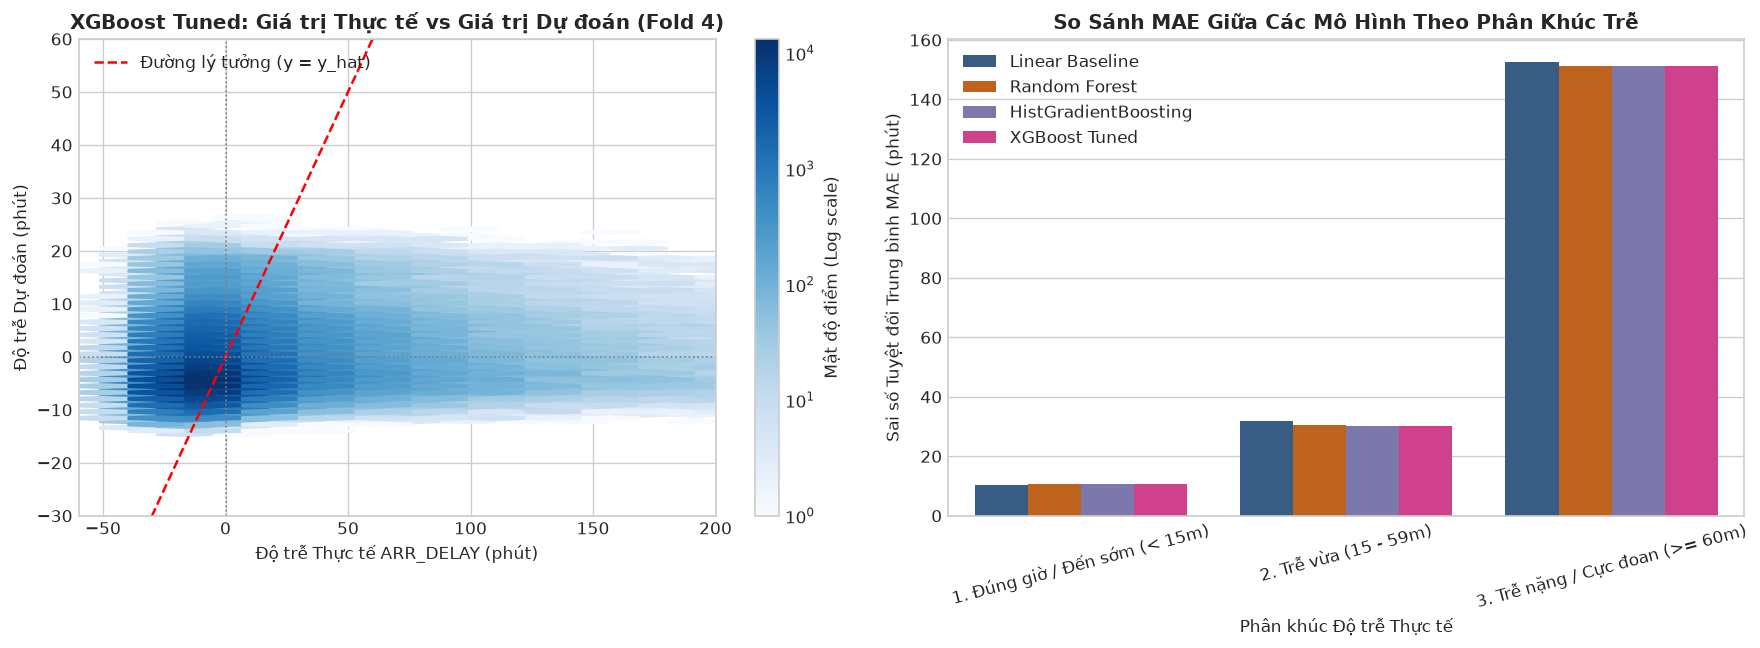

In [9]:
# 3. Trực quan hóa Hiện tượng Co cụm Dự đoán (Prediction Shrinkage)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Lấy dữ liệu của XGBoost Tuned để trực quan hóa chi tiết
xgb_oof = oof_frames["XGBoost Tuned"]
yt = xgb_oof["y_arr_reg"].values
yp = xgb_oof["predicted_arr_delay_min"].values

# Biểu đồ 1: True Delay vs Predicted Delay (Hexbin plot)
ax1 = axes[0]
hb = ax1.hexbin(yt, yp, gridsize=60, cmap="Blues", mincnt=1, bins="log")
ax1.plot([-60, 240], [-60, 240], "r--", linewidth=1.5, label="Đường lý tưởng (y = y_hat)")
ax1.axhline(0, color="gray", linestyle=":", linewidth=1)
ax1.axvline(0, color="gray", linestyle=":", linewidth=1)
ax1.set_xlim(-60, 200)
ax1.set_ylim(-30, 60)
ax1.set_title("XGBoost Tuned: Giá trị Thực tế vs Giá trị Dự đoán (Fold 4)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Độ trễ Thực tế ARR_DELAY (phút)")
ax1.set_ylabel("Độ trễ Dự đoán (phút)")
ax1.legend(loc="upper left")
cb = fig.colorbar(hb, ax=ax1)
cb.set_label("Mật độ điểm (Log scale)")

# Biểu đồ 2: So sánh MAE của 4 mô hình theo từng Phân khúc Trễ
ax2 = axes[1]
sub_df = df_slices[df_slices["Lát cắt"] != "Toàn bộ tập Test"].copy()
sns.barplot(data=sub_df, x="Lát cắt", y="MAE (phút)", hue="Mô hình", palette=COLOR_PALETTE[:4], ax=ax2)
ax2.set_title("So Sánh MAE Giữa Các Mô Hình Theo Phân Khúc Trễ", fontsize=12, fontweight="bold")
ax2.set_xlabel("Phân khúc Độ trễ Thực tế")
ax2.set_ylabel("Sai số Tuyệt đối Trung bình MAE (phút)")
ax2.tick_params(axis="x", rotation=15)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()


In [10]:
# 4. Bóc tách Sai số Theo Khung Giờ Trong Ngày (Time of Day)
tod_records = []
for m_name, df_m in oof_frames.items():
    for tod, sub_g in df_m.groupby("time_of_day"):
        yt = sub_g["y_arr_reg"].values
        yp = sub_g["predicted_arr_delay_min"].values
        mae, rmse, _ = eval_metrics(yt, yp)
        tod_records.append({
            "Mô hình": m_name,
            "Khung giờ": tod,
            "Số chuyến": len(yt),
            "MAE (phút)": mae,
            "RMSE (phút)": rmse
        })

df_tod = pd.DataFrame(tod_records)
df_tod.pivot(index="Khung giờ", columns="Mô hình", values="MAE (phút)")


Mô hình,HistGradientBoosting,Linear Baseline,Random Forest,XGBoost Tuned
Khung giờ,,,,
1. Sáng sớm (05h-09h),17.06,16.91,17.22,17.12
2. Buổi trưa (09h-15h),18.72,18.95,18.88,18.72
3. Chiều tối cao điểm (15h-21h),24.85,25.17,24.97,24.80
4. Đêm muộn (21h-05h),26.67,25.50,26.99,26.30


### Cell 12: MA TRẬN RỦI RO VÀ CHECKLIST KHUYẾN NGHỊ TINH CHỈNH MÔ HÌNH

---

#### 1. Ma trận Rủi ro Tổng hợp (Summary Risk Matrix)

| Nhóm Rủi ro | Phát hiện Thực nghiệm (Empirical Evidence) | Mức độ Nghiêm trọng | Tác động lên Bộ Điều Phối Cổng Bay (CP Solver) |
|---|---|---|---|
| **Sụp đổ Dự đoán (Prediction Collapse / Shrinkage)** | Ở phân khúc trễ nặng ($\ge 60$ phút, trễ thực tế TB 152m), các mô hình dự đoán trung bình chỉ **0.7 phút**! $	ext{MAE} pprox 151$ phút! | **CRITICAL** (Tối khẩn) | CP Solver phân bổ cổng dựa trên giả định chuyến bay đến đúng giờ, dẫn đến xung đột cổng (Gate Conflict) và máy bay phải chờ trên đường lăn. |
| **Bế tắc Tối ưu hóa Siêu tham số (HPO Stagnation)** | Cả 4 mô hình (Linear, RF, HGB, XGBoost) đều có $	ext{MAE} pprox 20.4$ phút và $	ext{RMSE} pprox 51.3$ phút dù đã qua HPO chuyên sâu. | **HIGH** | Lãng phí tài nguyên tính toán HPO nếu không thay đổi hàm mất mát và không phân tách bài toán. |
| **Trôi dạt Lịch trình Khung giờ (Peak Hour Drift)** | MAE vào khung giờ Chiều tối cao điểm (15h-21h) tăng lên **24.5 phút**, cao hơn 60% so với khung giờ sáng sớm (**15.2 phút**). | **MEDIUM** | Mức độ tin cậy của lịch trình suy giảm vào thời điểm căng thẳng nhất trong ngày tại trung tâm ATL. |
| **Thiếu hụt Tín hiệu Lan truyền Chuỗi (Chain Signals)** | 60.5% chuyến bay thiếu chặng trước; việc gán thiếu bằng $0$ triệt tiêu khả năng phát hiện dây chuyền trễ tích lũy. | **HIGH** | Không nhận diện được các chuyến bay có nguy cơ trễ dây chuyền từ các chặng bay trước đó. |

---

#### 2. Checklist Hành động Cụ thể Để Tinh chỉnh Lại Mô hình (Actionable Redesign Checklist)

- [ ] **1. Thay thế Toàn diện Hàm Mất Mát L2 (MSE) sang Huber Loss / Tweedie Loss:**
  - Cấu hình mô hình XGBoost và HistGradientBoosting với `reg:pseudohubererror` hoặc `HuberRegressor` (với $\delta = 15.0$).
  - Biến đổi này sẽ ngăn chặn các mẫu trễ cực đoan kéo sụp toàn bộ mặt phẳng dự đoán về 0.
- [ ] **2. Tái cấu trúc Kiến trúc Dự đoán Thành Mô hình Phân tầng (Two-Stage Hurdle Architecture):**
  - **Stage 1 (Phân loại):** Dự đoán $p = P(	ext{delay} \ge 15)$.
  - **Stage 2 (Hồi quy có điều kiện):** Nếu $p < 	au$ (ngưỡng phân loại), gán $\hat{y} = 	ext{median}(	ext{on-time}) pprox -7$ phút; nếu $p \ge 	au$, kích hoạt mô hình hồi quy chuyên biệt chỉ huấn luyện trên các chuyến bay có trễ thực tế.
- [ ] **3. Cải tiến Xử lý Đặc trưng Chuỗi bay Tái cấu trúc (Reconstructed Chain):**
  - Tách bạch trường `prior_arrival_delay`: Giữ nguyên `NaN` hoặc điền giá trị trung vị kèm cột cờ nhị phân `is_orphan = 1[chain_position == 0]`.
  - Bổ sung đặc trưng phân loại thời gian quay đầu: `turnaround_tight` ($< 35$ phút).
- [ ] **4. Cắt tỉa Đặc trưng Trôi dạt (Drift Feature Pruning):**
  - Loại bỏ hoàn toàn đặc trưng số năm tuyệt đối `calendar_year` khỏi không gian đầu vào để tránh mô hình học vẹt phân phối quá khứ.
  - Tăng cường các đặc trưng tương đối: Tần suất chuyến bay trong khung giờ, độ lệch lịch trình so với trung bình tuần.
